# Urban Safety — Risk Inspection & Pre-ML Analysis

Loads pre-computed segment features from `csv/features_all_boroughs_with_location_id_augmented.csv`, computes a normalized risk score and risk class, exports labelled CSV, and explores feature distributions prior to ML training.

**The augmented input keeps the existing feature columns and adds `public_transport_proximity_m` plus `dominant_land_use_score`.**

**See `03_London_ClassificationML.ipynb` for model training.**

## Cell 1 — Imports and config

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)

# ── File paths ────────────────────────────────────────────────────────────
FEATURES_CACHE = os.path.join('..', 'csv', 'features_all_boroughs_with_location_id_augmented.csv')

# ── Feature columns ───────────────────────────────────────────────────────
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score']

# ── Risk / safety config ──────────────────────────────────────────────
RISK_ORDER   = ['Low', 'Medium', 'High']
RISK_COLORS  = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
RISK_WEIGHTS = {'Low': 1, 'Medium': 2, 'High': 3}

## Cell 2 — Load pre-computed features
Loads the cached feature CSV produced by `00_DataFetching.ipynb` and includes the two OSM-derived enrichment columns.

In [6]:
features = pd.read_csv(FEATURES_CACHE)

# Keep only the five target boroughs
ALLOWED_BOROUGH_NAMES = [
    'City of Westminster, London, UK',
    'London Borough of Islington, London, UK',
    'London Borough of Hackney, London, UK',
    'London Borough of Tower Hamlets, London, UK',
    'London Borough of Southwark, London, UK',
]
if 'borough' in features.columns:
    before = len(features)
    features = features[features['borough'].isin(ALLOWED_BOROUGH_NAMES)].reset_index(drop=True)
    after = len(features)
    print(f'\u2713 Loaded {after:,} segments from {FEATURES_CACHE} (filtered from {before:,})')
    print(f'  Boroughs : {features["borough"].nunique()}')
    print(features['borough'].value_counts().to_string())
else:
    print(f'\u2713 Loaded {len(features):,} segments from {FEATURES_CACHE} (no borough column to filter)')

✓ Loaded 35,978 segments from ..\csv\features_all_boroughs_with_location_id_augmented.csv (filtered from 61,784)
  Boroughs : 5
borough
London Borough of Southwark, London, UK        9757
London Borough of Tower Hamlets, London, UK    7618
City of Westminster, London, UK                7558
London Borough of Hackney, London, UK          5863
London Borough of Islington, London, UK        5182


## Cell 3 — Risk score formula
Defined here for reference and validation. The score is derived from the normalized feature set.

In [9]:
def compute_risk_score(df):
    def norm(col):
        col = col.astype(float)
        min_val = col.min()
        max_val = col.max()
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
            return pd.Series(0.0, index=col.index)
        return (col - min_val) / (max_val - min_val)

    lighting = norm(df['lighting'].fillna(df['lighting'].median()))
    connectivity = norm(df['connectivity'].fillna(df['connectivity'].median()))
    enclosure = norm(df['enclosure'].fillna(df['enclosure'].median()))
    visibility = norm(df['visibility'].fillna(df['visibility'].median()))

    if 'public_transport_proximity_m' in df.columns:
        transport_raw = df['public_transport_proximity_m']
    elif {'dist_to_rail_m', 'dist_to_bus_m'}.issubset(df.columns):
        transport_raw = df[['dist_to_rail_m', 'dist_to_bus_m']].min(axis=1)
    else:
        transport_raw = pd.Series(0.0, index=df.index)
    transport = 1 - norm(transport_raw.fillna(transport_raw.median()).clip(upper=800))

    if 'dominant_land_use_score' in df.columns:
        landuse_raw = df['dominant_land_use_score']
    elif 'commercial_ratio' in df.columns:
        landuse_raw = df['commercial_ratio']
    else:
        landuse_raw = pd.Series(0.0, index=df.index)
    landuse = norm(landuse_raw.fillna(landuse_raw.median()))

    score = (
        -0.25 * lighting
        +0.15 * enclosure
        -0.15 * visibility
        -0.15 * connectivity
        -0.15 * transport
        -0.05 * landuse
    )

    if score.max() == score.min():
        return pd.Series(0.0, index=df.index)
    return (score - score.min()) / (score.max() - score.min())

## Cell 4 — Segment risk classification
Categorizes streets into 3 risk classes based on the normalized risk score:
Low (0–0.33), Medium (0.33–0.66), High (0.66+).

In [10]:
# ── Fixed-score binning ──────────────────────────────────────────────────
features['risk_score'] = compute_risk_score(features)

threshold_low_med = 0.33
threshold_med_high = 0.66

features['risk_class'] = pd.cut(
    features['risk_score'],
    bins=[0, threshold_low_med, threshold_med_high, 1.0],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)
features['risk_class'] = pd.Categorical(
    features['risk_class'],
    categories=['low', 'medium', 'high'],
    ordered=True
)
features['safety_class'] = features['risk_class']

print('Risk class thresholds (fixed-score bins):')
print(f'  low    : 0 to {threshold_low_med:.2f}')
print(f'  medium : {threshold_low_med:.2f} to {threshold_med_high:.2f}')
print(f'  high   : {threshold_med_high:.2f}+')
print(f'\nActual distribution:')
for label in ['low', 'medium', 'high']:
    mask = features['risk_class'] == label
    if mask.sum() > 0:
        min_val = features.loc[mask, 'risk_score'].min()
        max_val = features.loc[mask, 'risk_score'].max()
        pct = 100 * mask.sum() / len(features)
        print(f'  {label:10s} : {min_val:8.4f} to {max_val:8.4f} ({mask.sum():6,} segments, {pct:5.1f}%)')

Risk class thresholds (fixed-score bins):
  low    : 0 to 0.33
  medium : 0.33 to 0.66
  high   : 0.66+

Actual distribution:
  low        :   0.0000 to   0.3281 (    27 segments,   0.1%)
  medium     :   0.3342 to   0.6600 (22,065 segments,  61.3%)
  high       :   0.6600 to   1.0000 (13,886 segments,  38.6%)


In [ ]:
# Outlier detection: DISABLED (using all non-zero data)
print('Outlier detection: DISABLED (using all non-zero data, no filtering)')

## Cell 5 — Export labelled segment CSV

In [13]:
if 'location_id' not in features.columns:
    if 'osmid' in features.columns:
        features['location_id'] = features['borough'].str.extract(r'(\w+)')[0] + '_' + features['osmid'].astype(str)
    else:
        features['location_id'] = features['borough'].str.extract(r'(^[A-Za-z]+)')[0].str.upper() + '_' + features.index.astype(str)

segment_scores = features[['borough', 'lighting', 'visibility', 'connectivity', 'enclosure',
                            'public_transport_proximity_m', 'dominant_land_use_score',
                            'risk_score', 'risk_class', 'location_id']].copy()

output_path = os.path.join('..', 'csv', 'segment_risk_scores_w-id.csv')
segment_scores.to_csv(output_path, index=False)
print(f'\u2713 Exported {len(segment_scores):,} segments')
print(f'\u2713 Saved to {output_path}')
display(segment_scores.head(10))

✓ Exported 35,978 segments
✓ Saved to ..\csv\segment_risk_scores_w-id.csv


,borough,lighting,visibility,connectivity,enclosure,public_transport_proximity_m,dominant_land_use_score,risk_score,risk_class,location_id
0,"London Borough of Islington, London, UK",0.000,6.750,9,0.213,36.610,0.649,0.550,medium,ISL_16527_-27061
1,"London Borough of Islington, London, UK",0.000,0.000,8,0.201,68.360,0.362,0.613,medium,ISL_16528_-27064
2,"London Borough of Islington, London, UK",11.869,9.000,12,0.395,73.380,-0.779,0.587,medium,ISL_16683_-27082
3,"London Borough of Islington, London, UK",6.903,9.000,8,0.334,63.010,-0.665,0.662,high,ISL_16683_-27079
4,"London Borough of Islington, London, UK",4.117,12.000,12,0.329,24.330,-0.699,0.556,medium,ISL_16687_-27079
5,"London Borough of Islington, London, UK",7.018,9.667,12,0.378,40.660,-0.641,0.570,medium,ISL_16691_-27076
6,"London Borough of Islington, London, UK",2.091,15.000,11,0.343,27.500,-0.576,0.578,medium,ISL_16691_-27079
7,"London Borough of Islington, London, UK",4.117,12.000,12,0.329,24.330,-0.699,0.556,medium,ISL_16687_-27079
8,"London Borough of Islington, London, UK",4.382,9.000,11,0.342,99.880,-0.945,0.641,medium,ISL_16695_-27084
9,"London Borough of Islington, London, UK",2.871,9.000,12,0.356,136.740,-1.000,0.652,medium,ISL_16696_-27087


## Cell 6 — Class balance check
Verify that safe / low / medium / high are reasonably distributed before training.

In [14]:
print('=== RISK CLASS BALANCE CHECK ===\n')
overall = features['risk_class'].value_counts().sort_index()
print('Overall distribution:')
for label, count in overall.items():
    pct = 100 * count / len(features)
    bar = '\u2588' * int(pct / 2)
    print(f'  {label:10s}: {count:6,}  ({pct:5.1f}%)  {bar}')

print(f'\nPer-borough breakdown:')
borough_dist = (
    features.groupby('borough')['risk_class']
    .value_counts().unstack(fill_value=0)
)
borough_dist.index = [
    b.replace('London Borough of ', '').replace(', London, UK', '').replace('City of ', '')
    for b in borough_dist.index
]
print(borough_dist.to_string())

min_class_pct = 100 * overall.min() / len(features)
if min_class_pct < 10:
    print(f'\n\u26a0  Smallest class is only {min_class_pct:.1f}% - consider adjusting score thresholds.')
else:
    print(f'\n\u2713  All classes >= {min_class_pct:.1f}% - balance is acceptable for training.')

=== RISK CLASS BALANCE CHECK ===

Overall distribution:
  low       :     27  (  0.1%)  
  medium    : 22,065  ( 61.3%)  ██████████████████████████████
  high      : 13,886  ( 38.6%)  ███████████████████

Per-borough breakdown:
risk_class     low  medium  high
Westminster     12    3920  3626
Hackney          8    3995  1860
Islington        1    3372  1809
Southwark        0    5554  4203
Tower Hamlets    6    5224  2388

⚠  Smallest class is only 0.1% - consider adjusting score thresholds.


## Cell 7 — Crime score distribution plots

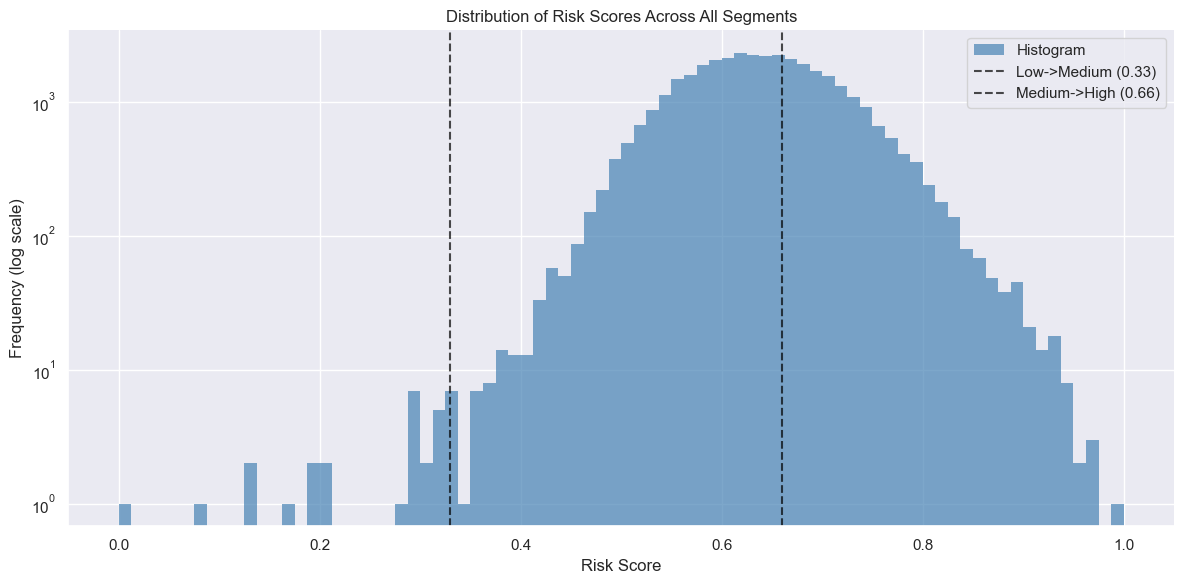

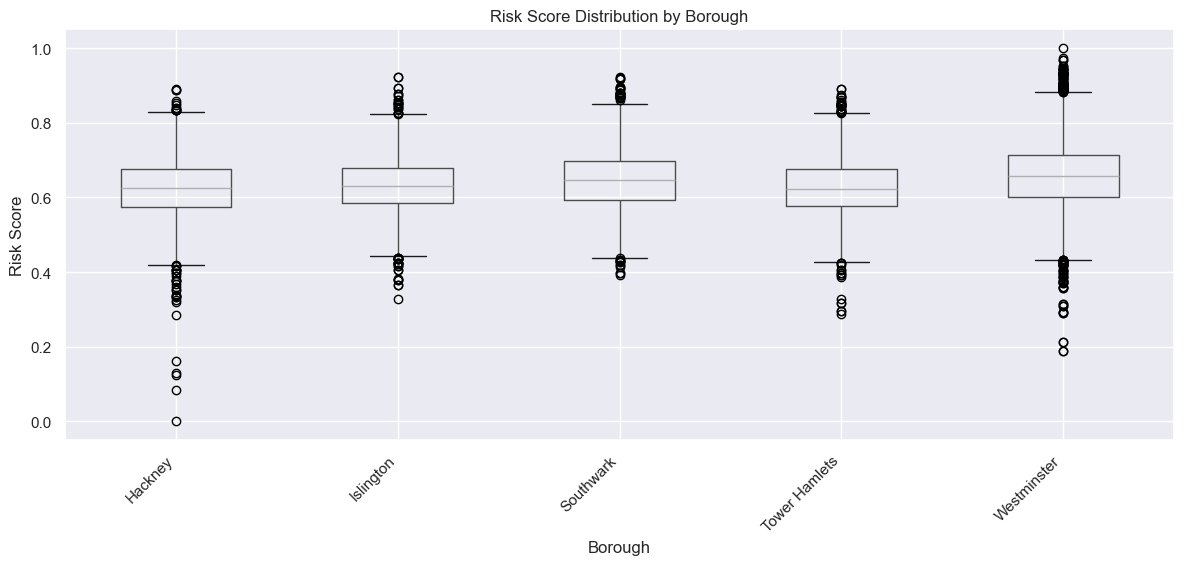

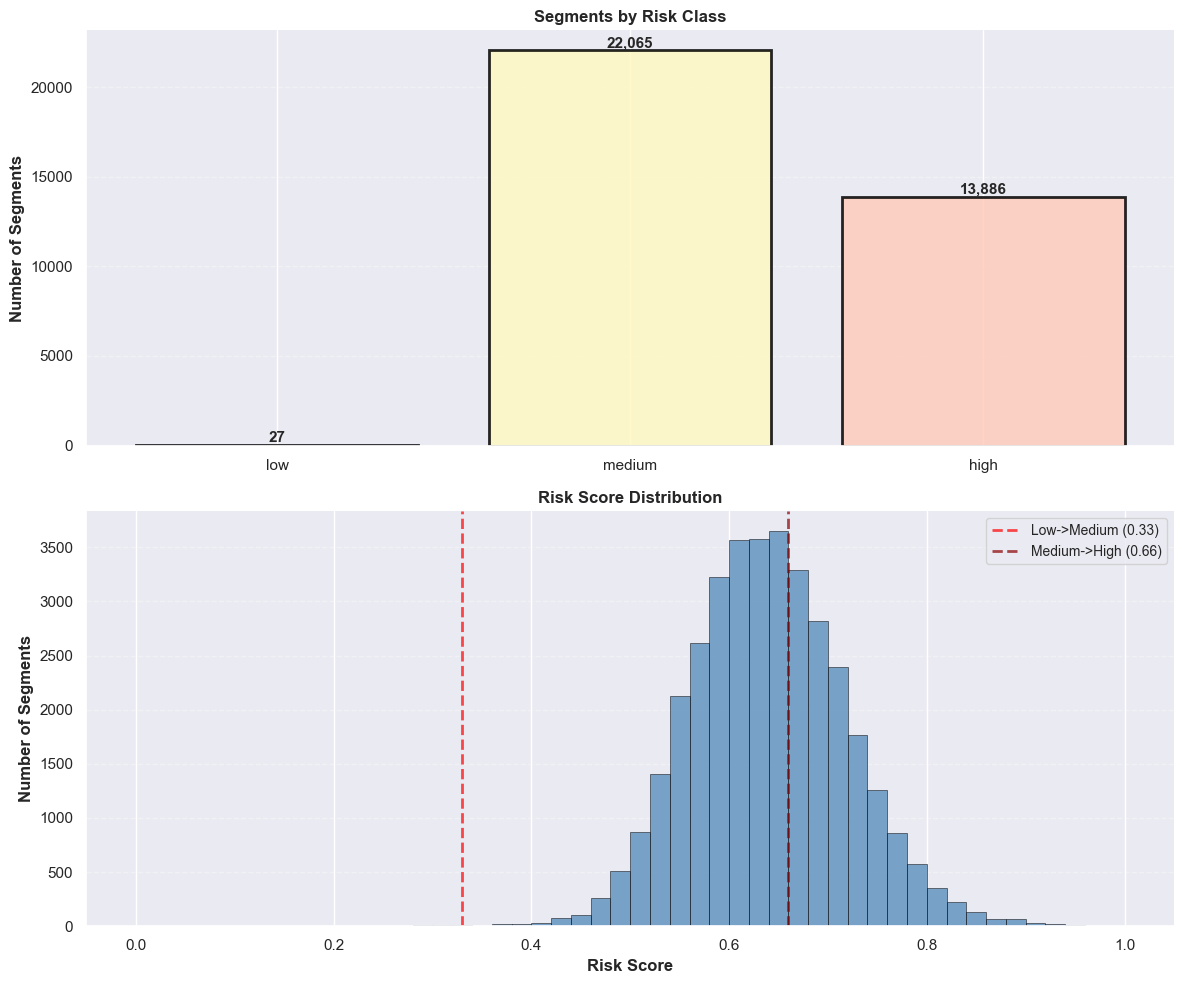

In [15]:
os.makedirs('plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(features['risk_score'], bins=80, color='steelblue', alpha=0.7, edgecolor='none', label='Histogram')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Frequency (log scale)')
ax.set_yscale('log')
ax.set_title('Distribution of Risk Scores Across All Segments')
ax.axvline(threshold_low_med, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Low->Medium ({threshold_low_med:.2f})')
ax.axvline(threshold_med_high, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Medium->High ({threshold_med_high:.2f})')
ax.set_xlim([features['risk_score'].min() - 0.05, features['risk_score'].max() + 0.05])
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
features_copy = features.copy()
features_copy['borough_short'] = (features_copy['borough']
    .str.replace('London Borough of ', '').str.replace(', London, UK', '').str.replace('City of ', ''))
features_copy.boxplot(column='risk_score', by='borough_short', ax=ax)
ax.set_xlabel('Borough'); ax.set_ylabel('Risk Score')
ax.set_title('Risk Score Distribution by Borough')
plt.suptitle(''); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/risk_score_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
class_counts = features['risk_class'].value_counts().reindex(['low', 'medium', 'high'])
colors_list = ['#C8E6C9', '#FFF9C4', '#FFCCBC']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_list, edgecolor='black',
                   linewidth=2, alpha=0.85)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[0].set_title('Segments by Risk Class', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(features['risk_score'], bins=50, color='steelblue', edgecolor='black',
             linewidth=0.5, alpha=0.7)
axes[1].set_xlabel('Risk Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[1].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(threshold_low_med, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Low->Medium ({threshold_low_med:.2f})')
axes[1].axvline(threshold_med_high, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Medium->High ({threshold_med_high:.2f})')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/risk_score_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature EDA — inspect the data and how it correlates

Non-spatial exploration of the 6 per-segment features, colored by `risk_class`.

In [ ]:
feat_df = features[FEATURE_COLS].copy()
print(f'Feature dataframe: {feat_df.shape[0]:,} segments x {feat_df.shape[1]} features')
display(feat_df.head(10))
summary = feat_df.describe().T
summary['skew'] = feat_df.skew()
print('Summary (with skew):')
display(summary.round(3))

sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 5))
corr = features[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation matrix (Pearson)')
plt.tight_layout()
plt.savefig('plots/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr.round(3))

In [ ]:
_order = ['low', 'medium', 'high']
_pal = {'low': '#C8E6C9', 'medium': '#FFF9C4', 'high': '#FFCCBC'}
_df = features[FEATURE_COLS + ['risk_class']].copy()
_df['risk_class'] = _df['risk_class'].astype('object')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    plot_data = _df[_df[col] > 0].copy() if col == 'lighting' else _df.copy()
    title_suffix = ' (non-zero lamps only)' if col == 'lighting' else ''
    sns.violinplot(data=plot_data, x='risk_class', y=col, order=_order,
                   palette=_pal, legend=False, inner='quartile', cut=0, ax=ax)
    ax.set_title(f'{col} by risk class{title_suffix}'); ax.set_xlabel('')
plt.suptitle('Feature distributions by risk class - Violin plots', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/feature_distributions_violin.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    plot_data = _df[_df[col] > 0].copy() if col == 'lighting' else _df.copy()
    title_suffix = ' (non-zero lamps only)' if col == 'lighting' else ''
    sns.stripplot(data=plot_data, x='risk_class', y=col, order=_order,
                  hue='risk_class', hue_order=_order, palette=_pal,
                  size=5, alpha=0.8, legend=False, ax=ax)
    ax.set_title(f'{col} by risk class{title_suffix}'); ax.set_xlabel('')
plt.suptitle('Feature distributions by risk class - Individual points', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('plots/feature_distributions_strip.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
_sample = _df.sample(n=min(2000, len(_df)), random_state=42)
pairplot = sns.pairplot(_sample, vars=FEATURE_COLS, hue='safety_class',
                        hue_order=_order, palette=_pal, corner=True,
                        plot_kws={'s': 12, 'alpha': 1.0})
pairplot.savefig('plots/feature_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from pandas.plotting import parallel_coordinates
_z = (features[FEATURE_COLS] - features[FEATURE_COLS].mean()) / features[FEATURE_COLS].std()
_z['safety_class'] = features['safety_class'].astype('object').values
_z = _z.dropna(subset=['safety_class']).sample(n=min(800, len(_z)), random_state=42)
_present = [c for c in _order if c in _z['safety_class'].unique()]
fig, ax = plt.subplots(figsize=(11, 6))
parallel_coordinates(_z[FEATURE_COLS + ['safety_class']], 'safety_class',
                     color=[_pal[c] for c in _present], alpha=0.5, ax=ax)
ax.set_title('Parallel coordinates by safety class (z-scored, sampled)')
ax.set_ylabel('crime score (z)')
plt.tight_layout()
plt.savefig('plots/parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()

## Exponential Crime Score Validation

Demonstrates the scoring formula with example crime configurations.

In [ ]:
print('=== Risk Score Summary ===\n')
print(f'Min risk_score: {features["risk_score"].min():.4f}')
print(f'Max risk_score: {features["risk_score"].max():.4f}')
print(f'Mean risk_score: {features["risk_score"].mean():.4f}')
print(f'Median risk_score: {features["risk_score"].median():.4f}')
print(f'\nRisk class distribution:')
print(features['risk_class'].value_counts().sort_index())

print('\n=== Example risk features ===\n')
display(features[['borough', 'lighting', 'visibility', 'connectivity', 'enclosure',
                  'public_transport_proximity_m', 'dominant_land_use_score',
                  'risk_score', 'risk_class']].head(10))